# Survival Analisys Lung Adenocarcinoma

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import concordance_index

import warnings
warnings.filterwarnings("ignore")

In [26]:
# Load data
df = pd.read_excel("Luad_mskcc_2023.xlsx")
df.head()

,Study ID,Patient ID,Sample ID,Adjuvant,Adjuvant Chemotherapy,Adjuvant Immunotherapy,Adjuvant Targeted,Adjuvant Therapy,Adjuvant XRT,Adrenal Met Status (Months),...,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TGF-Beta Pathway,TMB (nonsynonymous),TP53 Pathway,WNT Pathway
0,luad_mskcc_2023_met_organotropism,P-0000149,P-0000149-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,883.0,Metastasis,Female,Matched,No,9.982398,No,No
1,luad_mskcc_2023_met_organotropism,P-0000163,P-0000163-T02-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,439.0,Metastasis,Female,Matched,No,3.327466,Yes,No
2,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T01-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Primary,NaN,Matched,NaN,2.933333,NaN,NaN
3,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T02-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Metastasis,NaN,Matched,NaN,1.600000,NaN,NaN
4,luad_mskcc_2023_met_organotropism,P-0000219,P-0000219-T01-IM3,Yes,Yes,No,No,Yes,Yes,NaN,...,Tumor,1,1033.0,Primary,Female,Matched,Yes,4.436621,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 94 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Study ID                                      2653 non-null   object 
 1   Patient ID                                    2653 non-null   object 
 2   Sample ID                                     2653 non-null   object 
 3   Adjuvant                                      641 non-null    object 
 4   Adjuvant Chemotherapy                         880 non-null    object 
 5   Adjuvant Immunotherapy                        880 non-null    object 
 6   Adjuvant Targeted                             880 non-null    object 
 7   Adjuvant Therapy                              603 non-null    object 
 8   Adjuvant XRT                                  880 non-null    object 
 9   Adrenal Met Status (Months)                   38 non-null     f

## Preprocessing

In [27]:
# Pilih Variabel yang relevan untuk analisis
columns_needed = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Age at Surgery/Biopsy",
    "Sex",
    "Race Category",
    "Tobacco History",
    "TMB (nonsynonymous)",
    "Fraction Genome Altered",
    "Gene Panel",
    "Predominant Histologic Subtype",
    "Ever Met to Site: Liver",
    "Ever Met to Site: Bone",
    "Ever Met to Site: CNS",
    "Ever Met to Site: Pleura"
]

df = df[columns_needed].copy()


In [28]:
df.head()

,Overall Survival (Months),Overall Survival Status,Age at Surgery/Biopsy,Sex,Race Category,Tobacco History,TMB (nonsynonymous),Fraction Genome Altered,Gene Panel,Predominant Histologic Subtype,Ever Met to Site: Liver,Ever Met to Site: Bone,Ever Met to Site: CNS,Ever Met to Site: Pleura
0,NaN,NaN,51.254795,Female,Black,NaN,9.982398,0.2691,IMPACT341,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,38.487671,Female,White,NaN,3.327466,0.3584,IMPACT341,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,2.933333,NaN,WES,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,1.600000,NaN,WES,NaN,NaN,NaN,NaN,NaN
4,94.388007,0:LIVING,52.917808,Female,White,Ever,4.436621,0.0001,IMPACT341,Solid,0.0,1.0,0.0,0.0


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       882 non-null    float64
 1   Overall Survival Status         882 non-null    object 
 2   Age at Surgery/Biopsy           2422 non-null   float64
 3   Sex                             2554 non-null   object 
 4   Race Category                   2554 non-null   object 
 5   Tobacco History                 882 non-null    object 
 6   TMB (nonsynonymous)             2653 non-null   float64
 7   Fraction Genome Altered         2407 non-null   float64
 8   Gene Panel                      2653 non-null   object 
 9   Predominant Histologic Subtype  641 non-null    object 
 10  Ever Met to Site: Liver         766 non-null    float64
 11  Ever Met to Site: Bone          766 non-null    float64
 12  Ever Met to Site: CNS           76

In [29]:
# Cek missing values
df.isnull().sum()

Overall Survival (Months)         1771
Overall Survival Status           1771
Age at Surgery/Biopsy              231
Sex                                 99
Race Category                       99
Tobacco History                   1771
TMB (nonsynonymous)                  0
Fraction Genome Altered            246
Gene Panel                           0
Predominant Histologic Subtype    2012
Ever Met to Site: Liver           1887
Ever Met to Site: Bone            1887
Ever Met to Site: CNS             1887
Ever Met to Site: Pleura          1887
dtype: int64

In [30]:
# Ganti string 'NA' atau 'N/A' jadi NaN
df.replace(['NA', 'N/A', ''], np.nan, inplace=True)

# Drop semua baris yang memiliki missing pada kolom yang digunakan
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Ukuran Sampel Setelah Cleaning:", df.shape[0])

Ukuran Sampel Setelah Cleaning: 638


In [31]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       638 non-null    float64
 1   Overall Survival Status         638 non-null    object 
 2   Age at Surgery/Biopsy           638 non-null    float64
 3   Sex                             638 non-null    object 
 4   Race Category                   638 non-null    object 
 5   Tobacco History                 638 non-null    object 
 6   TMB (nonsynonymous)             638 non-null    float64
 7   Fraction Genome Altered         638 non-null    float64
 8   Gene Panel                      638 non-null    object 
 9   Predominant Histologic Subtype  638 non-null    object 
 10  Ever Met to Site: Liver         638 non-null    float64
 11  Ever Met to Site: Bone          638 non-null    float64
 12  Ever Met to Site: CNS           638 

In [15]:
# Mengubah nilai di kolom 'Overall Survival Status'
df['Overall Survival Status'] = df['Overall Survival Status'].map({'1:DECEASED': 1, '0:LIVING': 0})

# Tampilkan nilai unik setelah mapping untuk verifikasi
print("Nilai unik di kolom 'Overall Survival Status' setelah mapping:")
print(df['Overall Survival Status'].unique())

Nilai unik di kolom 'Overall Survival Status' setelah mapping:
[0 1]


In [32]:
# Encode status survival
df['Overall Survival Status'] = df['Overall Survival Status'].map({'1:DECEASED': 1, '0:LIVING': 0})

# Validasi mapping
assert df['Overall Survival Status'].isin([0, 1]).all(), "Ada nilai tidak valid di 'Overall Survival Status'"
df['Overall Survival Status'] = df['Overall Survival Status'].astype(int)
df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')

In [33]:
# Hapus baris dengan waktu <= 0
df = df[df['Overall Survival (Months)'] > 0].reset_index(drop=True)

In [34]:
# Encode metastasis sites
met_sites = [
    "Ever Met to Site: Liver",
    "Ever Met to Site: Bone",
    "Ever Met to Site: CNS",
    "Ever Met to Site: Pleura"
]

for col in met_sites:
    df[col] = df[col].astype(str).map({'1': 1, '0': 0, 'Yes': 1, 'No': 0}).fillna(0).astype(int)

In [35]:
# Simpan salinan mentah untuk KM (sebelum one-hot)
df_raw = df.copy()

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       638 non-null    float64
 1   Overall Survival Status         638 non-null    int64  
 2   Age at Surgery/Biopsy           638 non-null    float64
 3   Sex                             638 non-null    object 
 4   Race Category                   638 non-null    object 
 5   Tobacco History                 638 non-null    object 
 6   TMB (nonsynonymous)             638 non-null    float64
 7   Fraction Genome Altered         638 non-null    float64
 8   Gene Panel                      638 non-null    object 
 9   Predominant Histologic Subtype  638 non-null    object 
 10  Ever Met to Site: Liver         638 non-null    int64  
 11  Ever Met to Site: Bone          638 non-null    int64  
 12  Ever Met to Site: CNS           638 

In [37]:
# One-hot encoding untuk Cox model (optional untuk KM)
categorical_cols = [
    "Sex",
    "Race Category",
    "Tobacco History",
    "Gene Panel",
    "Predominant Histologic Subtype"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Jumlah sampel setelah encoding: {len(df_encoded)}")

Jumlah sampel setelah encoding: 638


In [39]:
# Cek frekuensi kategori langka
cat_vars = ["Race Category", "Tobacco History", "Gene Panel",
            "Predominant Histologic Subtype"]

for col in cat_vars:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Race Category value counts:
Race Category
White      512
Asian       72
Black       22
Unknown     17
Other       15
Name: count, dtype: int64

Tobacco History value counts:
Tobacco History
Ever     468
Never    170
Name: count, dtype: int64

Gene Panel value counts:
Gene Panel
IMPACT468    396
IMPACT410    209
IMPACT341     33
Name: count, dtype: int64

Predominant Histologic Subtype value counts:
Predominant Histologic Subtype
Acinar            298
Unknown           111
Solid              93
Lepidic            61
Papillary          39
Micropapillary     36
Name: count, dtype: int64


## EDA

In [40]:
print(df.info())
print("\nEvent rate:", df["Overall Survival Status"].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Overall Survival (Months)       638 non-null    float64
 1   Overall Survival Status         638 non-null    int64  
 2   Age at Surgery/Biopsy           638 non-null    float64
 3   Sex                             638 non-null    object 
 4   Race Category                   638 non-null    object 
 5   Tobacco History                 638 non-null    object 
 6   TMB (nonsynonymous)             638 non-null    float64
 7   Fraction Genome Altered         638 non-null    float64
 8   Gene Panel                      638 non-null    object 
 9   Predominant Histologic Subtype  638 non-null    object 
 10  Ever Met to Site: Liver         638 non-null    int64  
 11  Ever Met to Site: Bone          638 non-null    int64  
 12  Ever Met to Site: CNS           638 

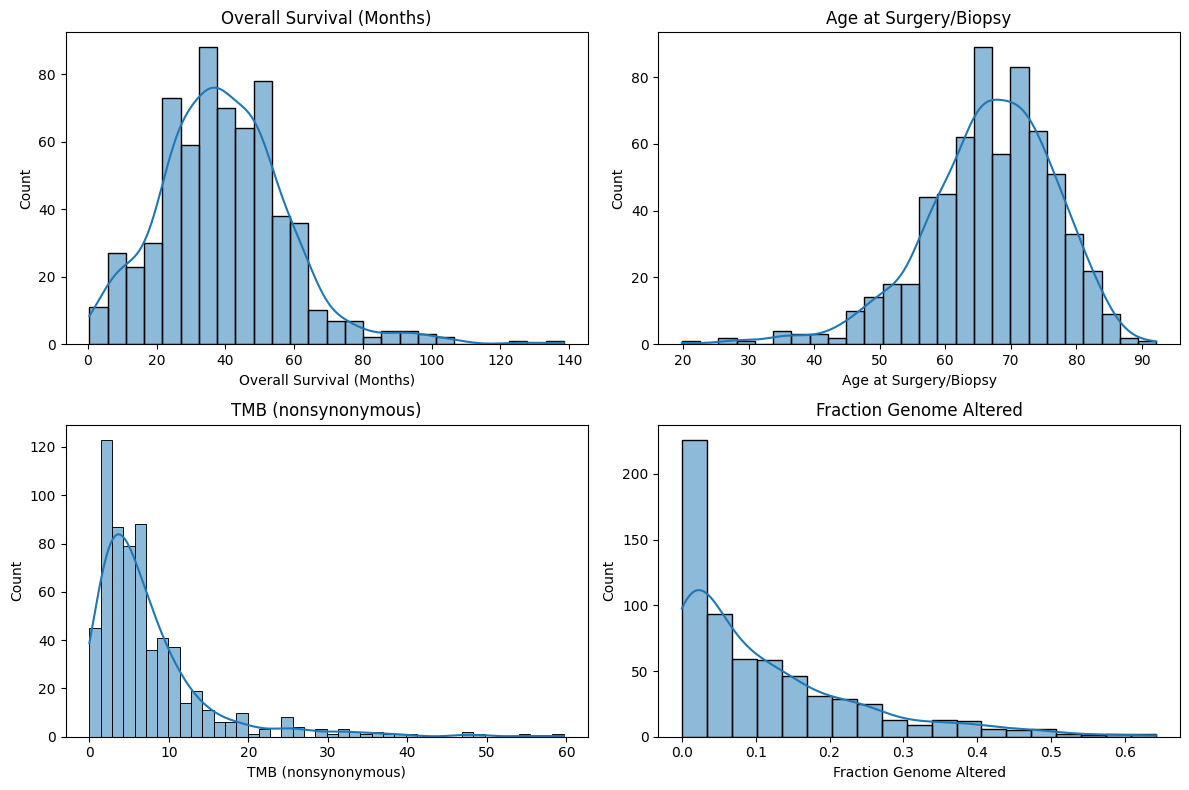

In [41]:
# Plot distribusi numerik
num_vars = [
    "Overall Survival (Months)",
    "Age at Surgery/Biopsy",
    "TMB (nonsynonymous)",
    "Fraction Genome Altered"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

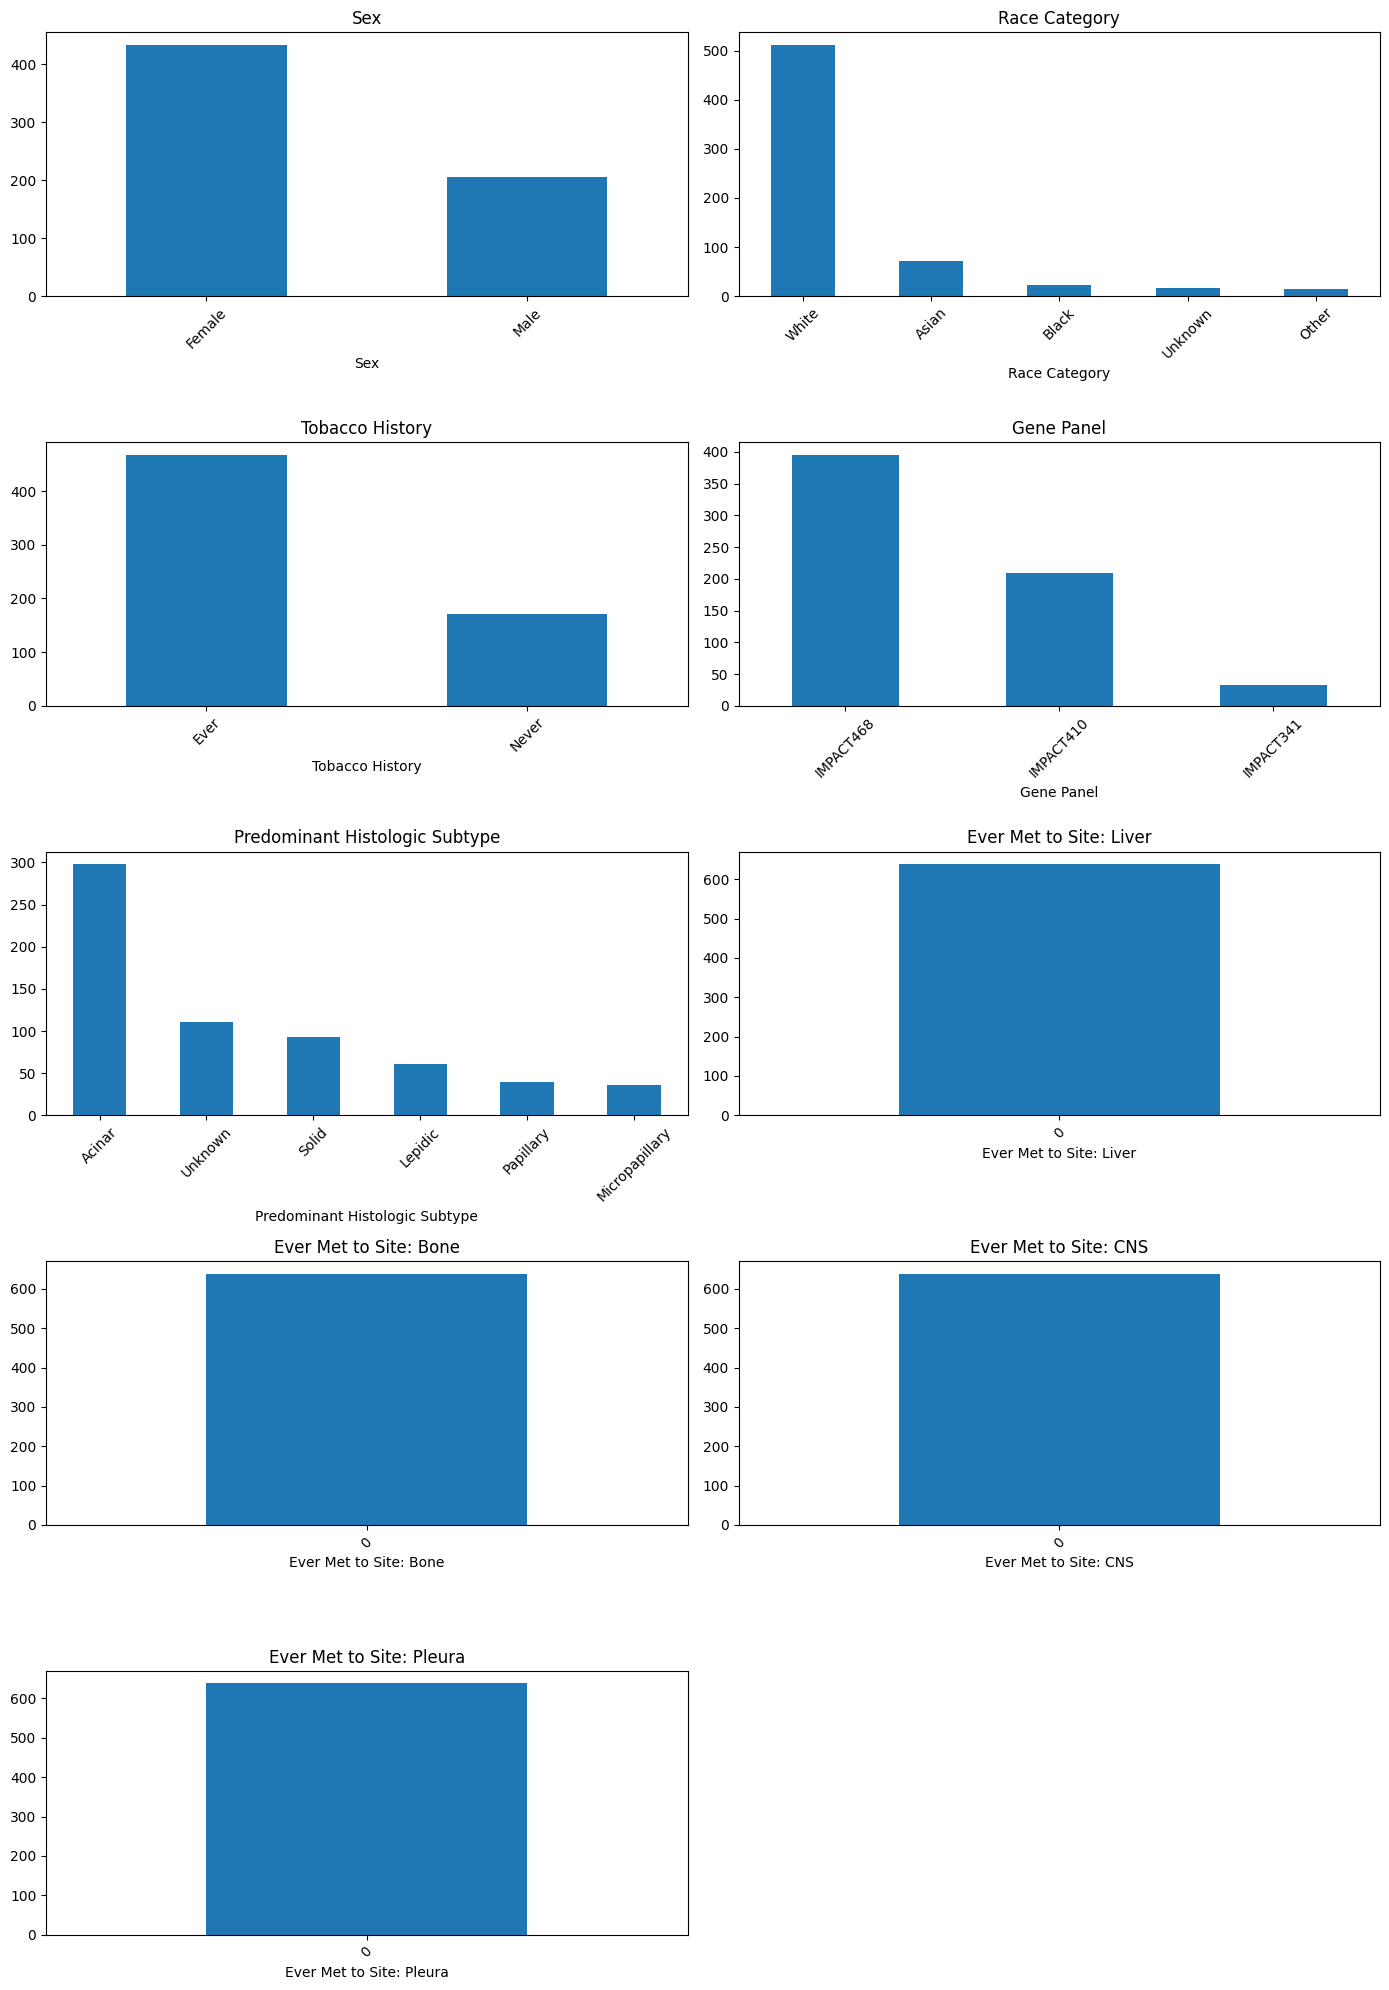

In [42]:
# Plot distribusi kategorikal
cat_vars = [
    "Sex", "Race Category", "Tobacco History",
    "Gene Panel", "Predominant Histologic Subtype"
] + met_sites

n_cols = 2
n_rows = int(np.ceil(len(cat_vars) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    df_raw[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Kaplan Meier


Menganalisis: Sex
   Kategori: ['Female', 'Male']


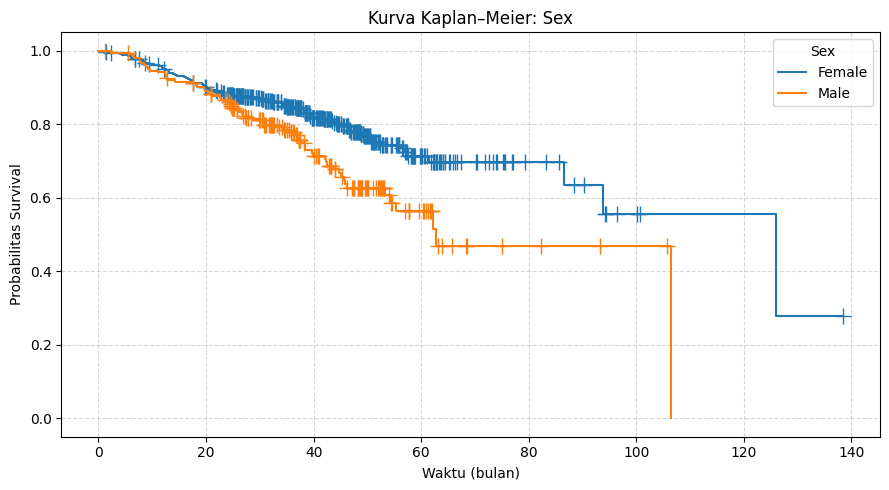

Log-rank p-value: 0.0014
Signifikan secara statistik (p < 0.05)

Menganalisis: Race Category
   Kategori: ['Asian', 'Black', 'Other', 'Unknown', 'White']


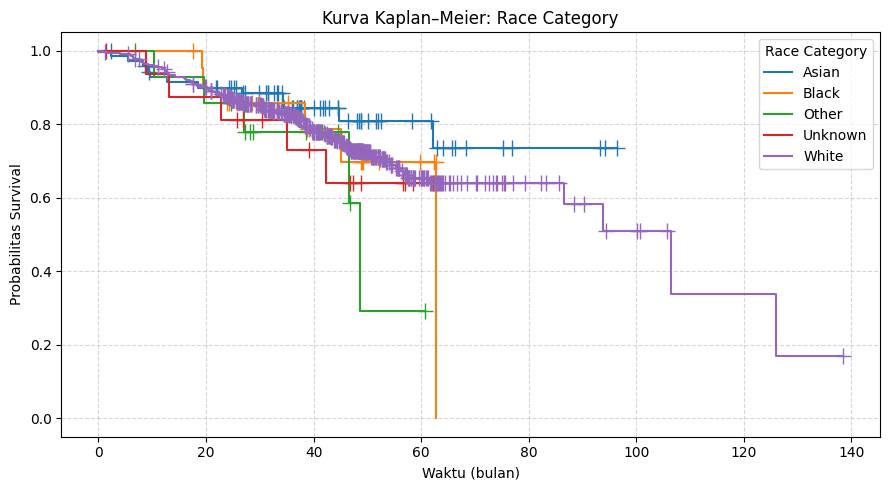

Log-rank p-value: 0.4970
Tidak signifikan

Menganalisis: Tobacco History
   Kategori: ['Ever', 'Never']


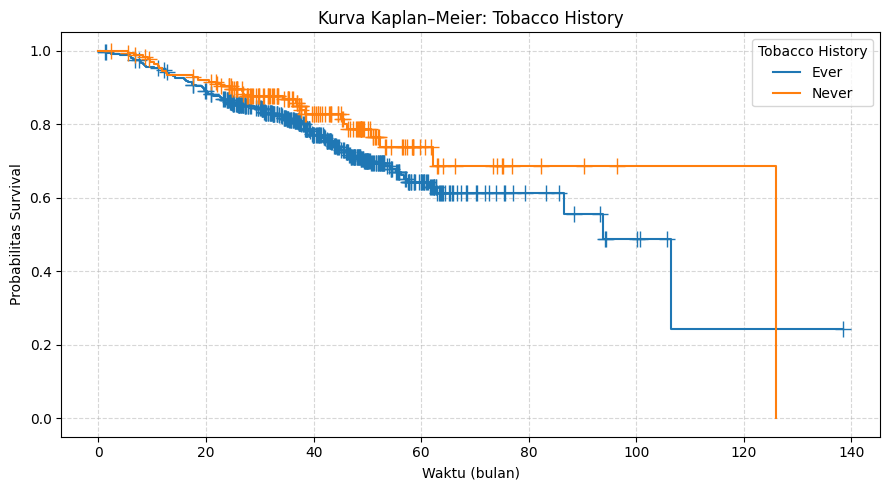

Log-rank p-value: 0.1014
Tidak signifikan

Menganalisis: Gene Panel
   Kategori: ['IMPACT341', 'IMPACT410', 'IMPACT468']


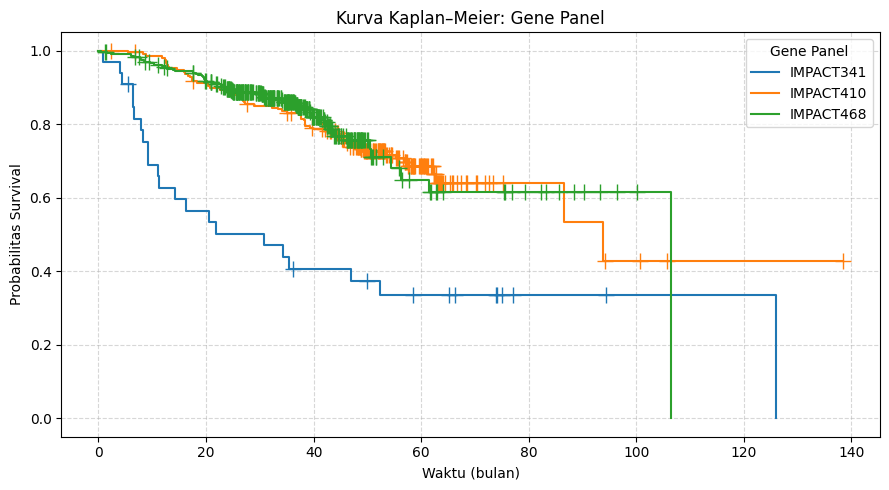

Log-rank p-value: 0.0000
Signifikan secara statistik (p < 0.05)

Menganalisis: Predominant Histologic Subtype
   Kategori: ['Acinar', 'Lepidic', 'Micropapillary', 'Papillary', 'Solid', 'Unknown']


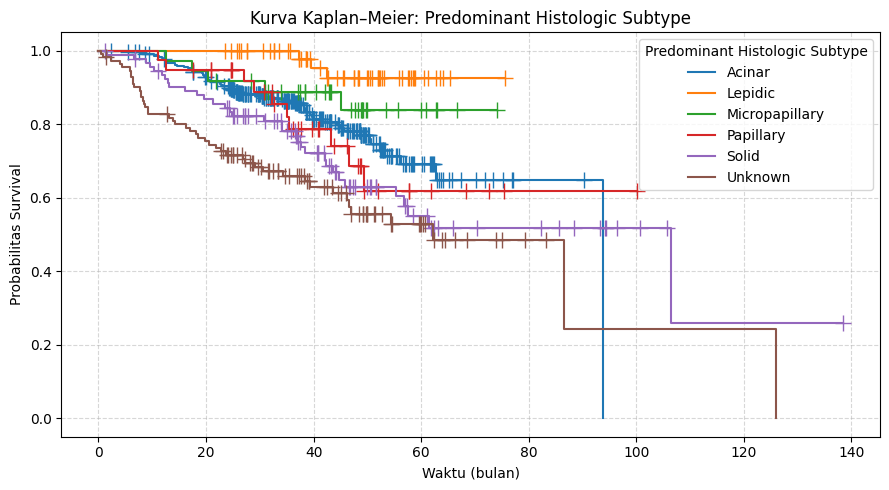

Log-rank p-value: 0.0000
Signifikan secara statistik (p < 0.05)


In [45]:
# Daftar variabel kategorikal (asli, belum one-hot)
categorical_vars = [
    "Sex",
    "Race Category",
    "Tobacco History",
    "Gene Panel",
    "Predominant Histologic Subtype",
]

# Loop setiap variabel kategorikal
for var in categorical_vars:
    if var not in df.columns:
        print(f"Kolom {var} tidak ditemukan. Lewati.")
        continue

    # Hanya gunakan baris dengan nilai valid di variabel ini
    df_var = df.dropna(subset=[var]).copy()
    unique_vals = df_var[var].unique()

    if len(unique_vals) < 2:
        print(f"Variabel {var} hanya punya 1 kategori. Lewati.")
        continue

    print(f"\nMenganalisis: {var}")
    print(f"   Kategori: {sorted(unique_vals)}")

    # Plot KM
    plt.figure(figsize=(9, 5))
    kmf = KaplanMeierFitter()

    for group in sorted(unique_vals):
        mask = df_var[var] == group
        if mask.sum() == 0:
            continue
        kmf.fit(
            df_var.loc[mask, "Overall Survival (Months)"],
            event_observed=df_var.loc[mask, "Overall Survival Status"],
            label=str(group)
        )
        kmf.plot_survival_function(ci_show=False, show_censors=True)

    plt.title(f"Kurva Kaplan–Meier: {var}")
    plt.xlabel("Waktu (bulan)")
    plt.ylabel("Probabilitas Survival")
    plt.legend(title=var)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Uji Log-rank
    if len(unique_vals) == 2:
        # Gunakan logrank_test untuk 2 grup
        groups = sorted(unique_vals)
        mask1 = df_var[var] == groups[0]
        mask2 = df_var[var] == groups[1]

        t1 = df_var.loc[mask1, "Overall Survival (Months)"]
        e1 = df_var.loc[mask1, "Overall Survival Status"]
        t2 = df_var.loc[mask2, "Overall Survival (Months)"]
        e2 = df_var.loc[mask2, "Overall Survival Status"]

        lr = logrank_test(t1, t2, event_observed_A=e1, event_observed_B=e2)
        p_val = lr.p_value
    else:
        # Gunakan multivariate_logrank_test untuk >2 grup
        lr = multivariate_logrank_test(
            df_var["Overall Survival (Months)"],
            df_var[var],
            df_var["Overall Survival Status"]
        )
        p_val = lr.p_value

    print(f"Log-rank p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("Signifikan secara statistik (p < 0.05)")
    else:
        print("Tidak signifikan")

## Regresi Cox


ℹ️  Events: 155, Fitur: 3

✅ MODEL COX BERHASIL DIFIT
                             coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                                
Age at Surgery/Biopsy    0.001596   1.001597  0.003560       -0.005381   
TMB (nonsynonymous)      0.004427   1.004437  0.004588       -0.004565   
Fraction Genome Altered  0.366842   1.443171  0.280947       -0.183803   

                         coef upper 95%  exp(coef) lower 95%  \
covariate                                                      
Age at Surgery/Biopsy          0.008573             0.994633   
TMB (nonsynonymous)            0.013420             0.995445   
Fraction Genome Altered        0.917488             0.832100   

                         exp(coef) upper 95%  cmp to         z         p  \
covariate                                                                  
Age at Surgery/Biopsy               1.008610     0.0  0.448324  0.653919   
TMB (nonsynonymous)      

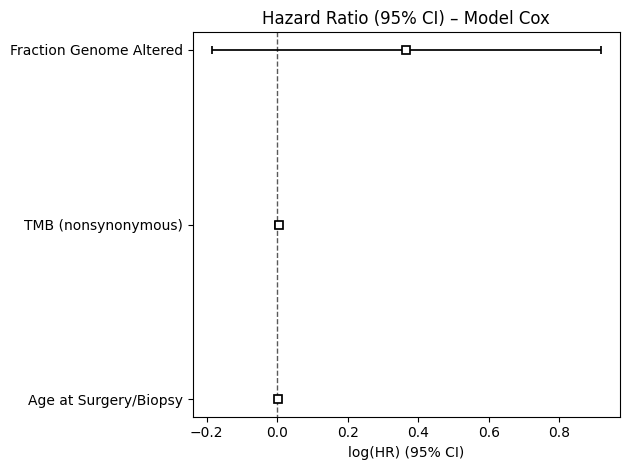


UJI ASUMSI PROPORTIONAL HAZARDS
Proportional hazard assumption looks okay.


In [47]:
# ========== 4. Regresi Cox (dengan penanganan error konvergensi) ==========
# Siapkan data Cox
data_cox_encoded = df_encoded.copy()

# Hanya ambil kolom numerik
data_cox_encoded = data_cox_encoded.select_dtypes(include=[np.number])

# Drop baris NaN (jika ada)
data_cox_encoded = data_cox_encoded.dropna()

# HAPUS KOLOM KONSTAN (penyebab utama singular matrix)
data_cox_encoded = data_cox_encoded.loc[:, data_cox_encoded.nunique() > 1]

# Cek rasio event vs fitur
n_events = data_cox_encoded["Overall Survival Status"].sum()
n_features = data_cox_encoded.shape[1] - 2
print(f"\nℹ️  Events: {n_events}, Fitur: {n_features}")
if n_events < 10 * n_features:
    print("⚠️  Rasio event/fitur rendah. Model mungkin tidak stabil.")

# Coba dengan penalizer lebih besar
try:
    cph = CoxPHFitter(penalizer=1.0, alpha=0.05)
    cph.fit(
        data_cox_encoded,
        duration_col='Overall Survival (Months)',
        event_col='Overall Survival Status',
        show_progress=False
    )
    
    print("\n" + "="*50)
    print("✅ MODEL COX BERHASIL DIFIT")
    print("="*50)
    print(cph.summary)

    # Plot HR
    cph.plot()
    plt.title("Hazard Ratio (95% CI) – Model Cox")
    plt.tight_layout()
    plt.show()

    # Uji asumsi PH
    print("\n" + "="*50)
    print("UJI ASUMSI PROPORTIONAL HAZARDS")
    print("="*50)
    cph.check_assumptions(data_cox_encoded, p_value_threshold=0.05, show_plots=False)

except Exception as e:
    print("\n❌ Gagal fitting model Cox:")
    print(e)
    print("\n💡 Saran:")
    print("- Kurangi jumlah fitur (misal: hanya gunakan variabel klinis utama)")
    print("- Naikkan `penalizer` (coba 2.0, 5.0)")
    print("- Pastikan tidak ada kategori langka di data asli")

In [46]:
# Pastikan hanya kolom numerik yang digunakan
data_cox_encoded = df_encoded.select_dtypes(include=[np.number]).dropna()

# Fit model Cox dengan penalizer
cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    data_cox_encoded,
    duration_col='Overall Survival (Months)',
    event_col='Overall Survival Status'
)

# Tampilkan hasil
print("\n" + "="*50)
print("SUMMARY MODEL COX PROPORTIONAL HAZARDS")
print("="*50)
print(cph.summary)

# Visualisasi HR
cph.plot()
plt.title("Hazard Ratio (95% CI) – Model Cox")
plt.tight_layout()
plt.show()

# Uji asumsi Proportional Hazards
print("\n" + "="*50)
print("UJI ASUMSI PROPORTIONAL HAZARDS")
print("="*50)
try:
    cph.check_assumptions(data_cox_encoded, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"Error saat uji asumsi PH: {e}")

ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

# Kaplan sebelum e

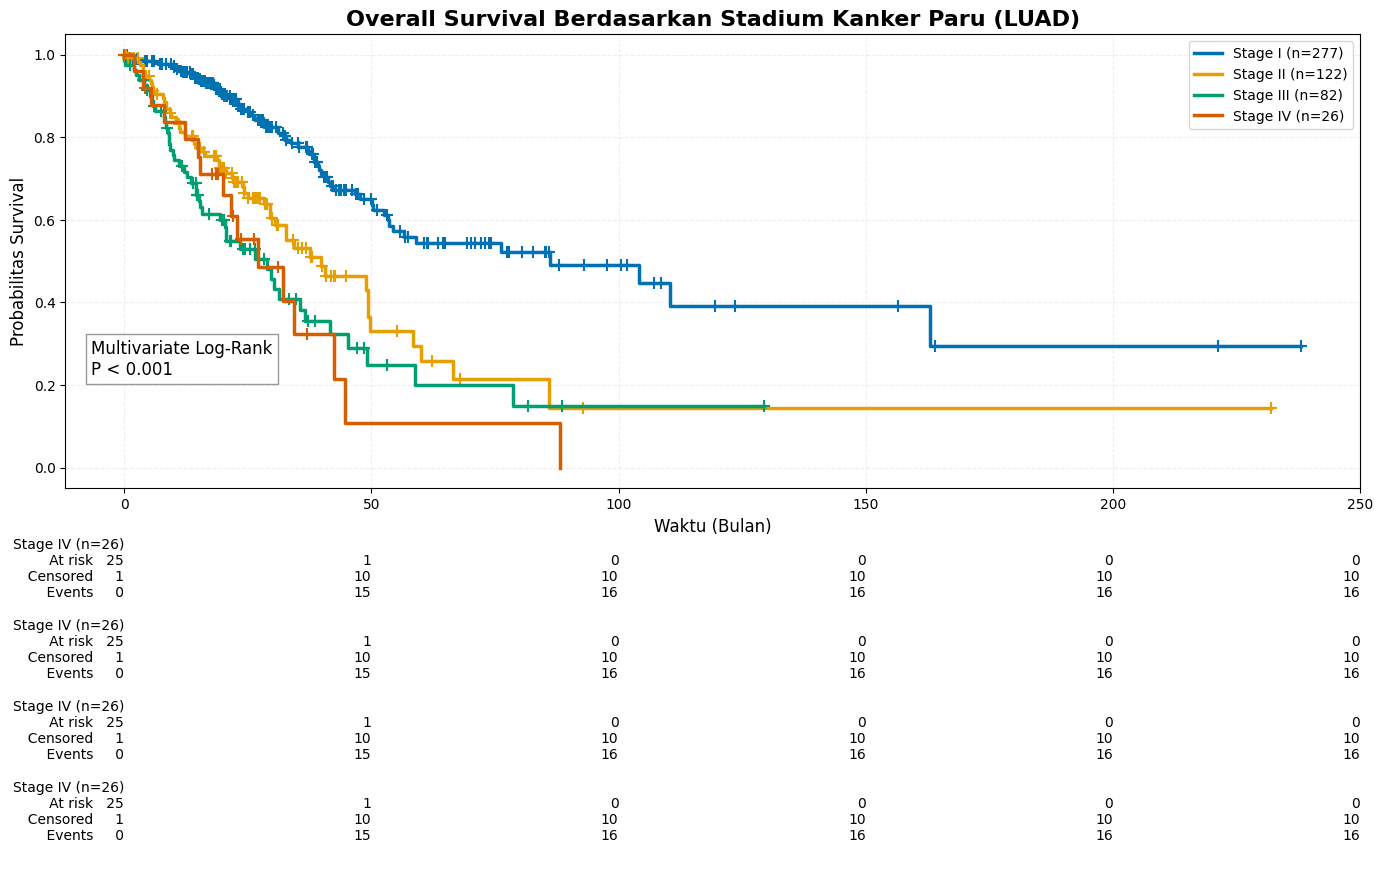

In [ ]:
# Setup Plot
fig, ax = plt.subplots(figsize=(14, 9))
kmf = KaplanMeierFitter()
fitters = [] # List untuk menyimpan objek kmf per grup

# Warna khusus agar kontras (Colorblind friendly palette)
colors = ['#0072B2', "#E69F00", '#009E73', '#D55E00'] 
stage_labels = {1: 'Stage I', 2: 'Stage II', 3: 'Stage III', 4: 'Stage IV'}

# Loop Plotting per Stadium
sorted_stages = sorted(df_clean['stage'].unique())

for i, stage_val in enumerate(sorted_stages):
    mask = df_clean['stage'] == stage_val
    n_patients = mask.sum()
    
    if n_patients == 0: continue
    
    # Label harus dinamis
    label_txt = f"{stage_labels.get(stage_val, f'Stage {stage_val}')} (n={n_patients})"
    
    kmf.fit(df_clean.loc[mask, 'time'], df_clean.loc[mask, 'event'], label=label_txt)
    
    kmf.plot_survival_function(
        ax=ax, 
        ci_show=False, 
        linewidth=2.5, 
        color=colors[i % len(colors)],
        show_censors=True,
        censor_styles={'marker': '+', 'ms': 8, 'mew': 1.5}
    )
    fitters.append(kmf)

# --- MENAMBAHKAN NUMBER AT RISK TABLE (Fitur Kunci) ---
add_at_risk_counts(*fitters, 
    ax=ax, 
    rows_to_show=['At risk', 'Censored', 'Events']
    )

# Menambahkan P-Value Log-Rank
res = multivariate_logrank_test(df_clean['time'], df_clean['stage'], df_clean['event'])
p_text = "P < 0.001" if res.p_value < 0.001 else f"P = {res.p_value:.4f}"

ax.text(0.02, 0.25, f'Multivariate Log-Rank\n{p_text}', transform=ax.transAxes, 
        fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Grafik
ax.set_title('Overall Survival Berdasarkan Stadium Kanker Paru (LUAD)', fontsize=16, weight='bold')
ax.set_ylabel('Probabilitas Survival', fontsize=12)
ax.set_xlabel('Waktu (Bulan)', fontsize=12)
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# --- SUMMARY UJI LOG-RANK (MULTIVARIATE) ---
print("\n[HASIL UJI LOG-RANK MULTIVARIAT]")
result = multivariate_logrank_test(
    event_durations=df_clean['time'], 
    groups=df_clean['stage'], 
    event_observed=df_clean['event']
)

# Menampilkan Summary Statistik
print(result.summary)

print(f"\nKesimpulan Statistik (p-value = {result.p_value:.10f}):")
if result.p_value < 0.05:
    print(">> TOLAK H0: Terdapat perbedaan signifikan pada kurva survival antar stadium.")
else:
    print(">> GAGAL TOLAK H0: Tidak cukup bukti untuk menyatakan kurva survival berbeda antar stadium.")



[HASIL UJI LOG-RANK MULTIVARIAT]
   test_statistic             p   -log2(p)
0       61.850324  2.365062e-13  41.943187

Kesimpulan Statistik (p-value = 0.0000000000):
>> TOLAK H0: Terdapat perbedaan signifikan pada kurva survival antar stadium.


## Kaplan Meier pada Gender

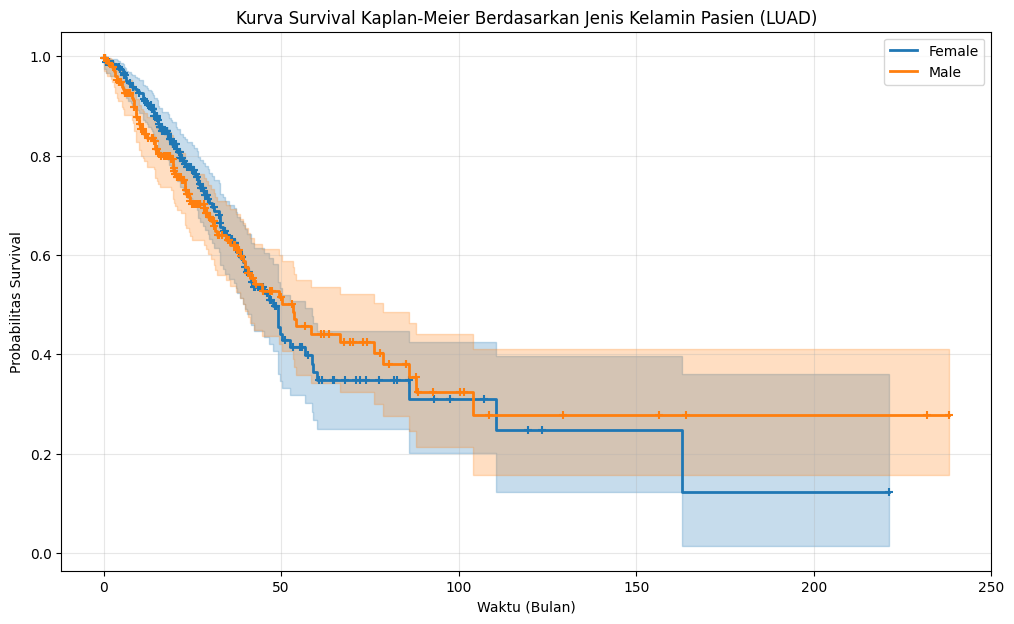

In [ ]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(12, 7))

# Dictionary untuk label 
stage_labels = {1: 'Male', 0: 'Female'}

# Loop melalui setiap stadium unik (1, 2, 3, 4) yang diurutkan
for stage_val in sorted(df_clean['sex'].unique()):
    # Filter data hanya untuk stadium tersebut
    mask = df_clean['sex'] == stage_val
    
    # Jika data ada, lakukan fitting
    if mask.sum() > 0:
        label_text = stage_labels.get(stage_val, f'Stage {stage_val}')
        kmf.fit(df_clean.loc[mask, 'time'], df_clean.loc[mask, 'event'], label=label_text)
        
        # Plot tanpa Confidence Interval (ci_show=False)
        # Jika ingin melihat interval kepercayaan, ubah jadi True
        kmf.plot_survival_function(
            ci_show=True, 
            linewidth=2,
            show_censors=True, 
            censor_styles={'marker': '+', 'ms': 6, 'mew': 1.5})

plt.title('Kurva Survival Kaplan-Meier Berdasarkan Jenis Kelamin Pasien (LUAD)')
plt.ylabel('Probabilitas Survival')
plt.xlabel('Waktu (Bulan)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- SUMMARY UJI LOG-RANK (MULTIVARIATE) ---
print("\n[HASIL UJI LOG-RANK MULTIVARIAT]")
result = multivariate_logrank_test(
    event_durations=df_clean['time'], 
    groups=df_clean['sex'], 
    event_observed=df_clean['event']
)

# Menampilkan Summary Statistik
print(result.summary)

print(f"\nKesimpulan Statistik (p-value = {result.p_value:.10f}):")
if result.p_value < 0.05:
    print(">> TOLAK H0: Terdapat perbedaan signifikan pada kurva survival antar jenis kelamin.")
else:
    print(">> GAGAL TOLAK H0: Tidak cukup bukti untuk menyatakan kurva survival berbeda antar jenis kelamin.")


[HASIL UJI LOG-RANK MULTIVARIAT]
   test_statistic         p  -log2(p)
0        0.054274  0.815786  0.293737

Kesimpulan Statistik (p-value = 0.8157860153):
>> GAGAL TOLAK H0: Tidak cukup bukti untuk menyatakan kurva survival berbeda antar jenis kelamin.
